/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


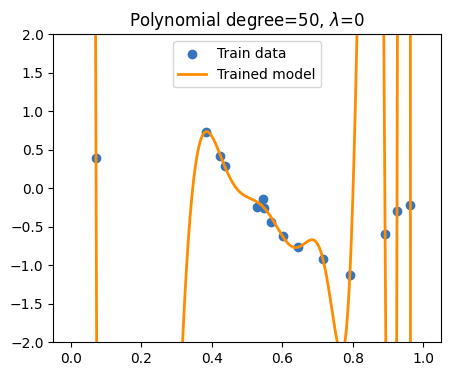

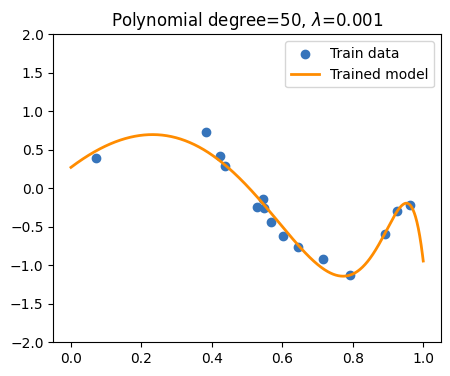

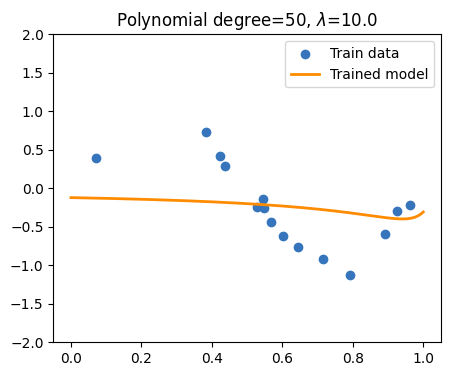

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from pathlib import Path

# Define the true function
def true_function(u):
    return np.sin(2 * np.pi * u)

# Generate data points
np.random.seed(0)
n = 15
u = np.random.rand(n)
y = true_function(u) + np.random.normal(0, 0.1, n)  # Reduced noise for better visualization

# Define polynomial degree and regularization strengths
degree = 50
lambdas = [0, 1e-3, 1e1]

# Define colors
colors = {
    'blue': '#3674BB',
    'dark orange': '#FF8C00',
}

# Generate points for plotting the fitted curves
u_plot = np.linspace(0, 1, 1000)

for alpha in lambdas:
    model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=alpha))
    model.fit(u[:, np.newaxis], y)

    # Predictions
    y_pred = model.predict(u_plot[:, np.newaxis])
    
    # Plot
    plt.figure(figsize=(5, 4))
    plt.scatter(u, y, color=colors['blue'], marker='o', label='Train data')
    plt.plot(u_plot, y_pred, color=colors['dark orange'], linewidth=2, label='Trained model')
    plt.title(f"Polynomial degree={degree}, $\lambda$={alpha}")

    plt.ylim(-2, 2)
    plt.legend()

    # Save figure
    filename = f"ridge_regression_p100_lambda_{alpha:.0e}.png"
    plt.show()